In [ ]:
# from typing import TypedDict

# class InputState(TypedDict):
#     user_input: str

# class OutputState(TypedDict):
#     graph_output:str

# class OverallState(TypedDict):
#     foo:str
#     user_input:str
#     graph_output: str

# class PrivateState(TypedDict):
#     bar: str

In [ ]:

# def node_1(state: InputState) -> OverallState:
#     # Write to OverallState
#     return {"foo": state["user_input"] + " name"}

# def node_2(state: OverallState) -> PrivateState:
#     # Read from OverallState, write to PrivateState
#     return {"bar": state["foo"] + " is"}

# def node_3(state: PrivateState) -> OutputState:
#     # Read from PrivateState, write to OutputState
#     return {"graph_output": state["bar"] + " Lance"}


In [ ]:
# %%capture --no-stderr
# %pip install -U langgraph

In [ ]:
# from langgraph.graph import StateGraph, START, END
# from typing import TypedDict

# # #define the schema for the input 
# # class InputState(TypedDict):
# #     question: str

# # class OutputState(TypedDict):
# #     answer: str

# # class OverallState(TypedDict):
# #     pass

# # def answer_node(state: InputState):
# #     return{"answer": "bye", "question": state["question"]}

# # #builder functiom

# # builder = StateGraph(OverallState, input=InputState, output=OutputState)
# # builder.add_node(answer_node)
# # builder.add_edge(START, "answer_node")
# # builder.add_edge("answer_node", END)
# # graph =builder.compile()

# # print(graph.invoke({"question": "hi"}))

In [ ]:
#  # The overall state of the graph (this is the public state shared across nodes)
# class OverallState(TypedDict):
#     a: str


# # Output from node_1 contains private data that is not part of the overall state
# class Node1Output(TypedDict):
#     private_data: str


# # The private data is only shared between node_1 and node_2
# def node_1(state: OverallState) -> Node1Output:
#     output = {"private_data": "set by node_1"}
#     print(f"Entered node `node_1`:\n\tInput: {state}.\n\tReturned: {output}")
#     return output


# # Node 2 input only requests the private data available after node_1
# class Node2Input(TypedDict):
#     private_data: str


# def node_2(state: Node2Input) -> OverallState:
#     output = {"a": "set by node_2"}
#     print(f"Entered node `node_2`:\n\tInput: {state}.\n\tReturned: {output}")
#     return output

# # Node 3input only requests the private data available after node_1
# class Node3Input(TypedDict):
#     private_data: str

# # Node 3 only has access to the overall state (no access to private data from node_1)
# def node_3(state: OverallState) -> OverallState:
#     output = {"a": "set by node_3"}
#     print(f"Entered node `node_3`:\n\tInput: {state}.\n\tReturned: {output}")
#     return output

# def node_4(state:OverallState) -> OverallState:
#     output = {"a": "set by node_4"}
#     print(f"Entered node `node_4`:\n\tInput: {state}.\n\tReturned: {output}")
#     return output


# # Build the state graph
# builder = StateGraph(OverallState)
# builder.add_node(node_1)  # node_1 is the first node
# builder.add_node(
#     node_2
# )  # node_2 is the second node and accepts private data from node_1
# builder.add_node(node_3)  # node_3 is the third node and does not see the private data
# builder.add_node(node_4)
# builder.add_edge(START, "node_1")  # Start the graph with node_1
# builder.add_edge("node_1", "node_2")  # Pass from node_1 to node_2
# builder.add_edge(
#     "node_2", "node_3")
# builder.add_edge("node_3", "node_4")
#   # Pass from node_2 to node_3 (only overall state is shared)
# builder.add_edge("node_4", END)  # End the graph after node_3
# graph = builder.compile()

# # Invoke the graph with the initial state
# response = graph.invoke(
#     {
#         "a": "set at start",
#     }
# )

# print()
# print(f"Output of graph invocation: {response}")

Entered node `node_1`:
	Input: {'a': 'set at start'}.
	Returned: {'private_data': 'set by node_1'}
Entered node `node_2`:
	Input: {'private_data': 'set by node_1'}.
	Returned: {'a': 'set by node_2'}
Entered node `node_3`:
	Input: {'a': 'set by node_2'}.
	Returned: {'a': 'set by node_3'}
Entered node `node_4`:
	Input: {'a': 'set by node_3'}.
	Returned: {'a': 'set by node_4'}

Output of graph invocation: {'a': 'set by node_4'}


In [ ]:
# from IPython.display import Image, display
# try:
#     display(Image(graph.get_graph().draw_mermaid_png()))
# except Exception:
#     # This requires some extra dependencies and is optional
#     pass

In [ ]:
# from typing import TypedDict
# class State(TypedDict):
#     name : str
#     weather_info: str

In [ ]:
# import random
# from typing import Literal
# def weather(state: State):
#     return {"weather_info" : "Hi!, I don't know.....But....."}

# def rainy_day(state: State):
#     # name = state.get(name)
#     return {"weather_info": "It's a rainy day today"}

# def sunny_day(state: State):
#     # name = state.get(name)
#     return {"weather_info": "Hi It's a sunny day today"}

# def forecast_weather(str)->Literal["rainy", "sunny"]:
#   if random.random() < 0.5:
#     return "rainy"
#   else:
#     return "sunny"    


In [ ]:
# from langgraph.graph import StateGraph, START, END
# workflow = StateGraph(State)
# # Add the nodes
# workflow.add_node("weather", weather)
# workflow.add_node("rainy", rainy_day)
# workflow.add_node("sunny", sunny_day)
# workflow.add_edge(START, "weather")
# workflow.add_conditional_edges("weather", forecast_weather)
# workflow.add_edge("rainy", END)
# workflow.add_edge("sunny", END)


In [ ]:
# app = workflow.compile()


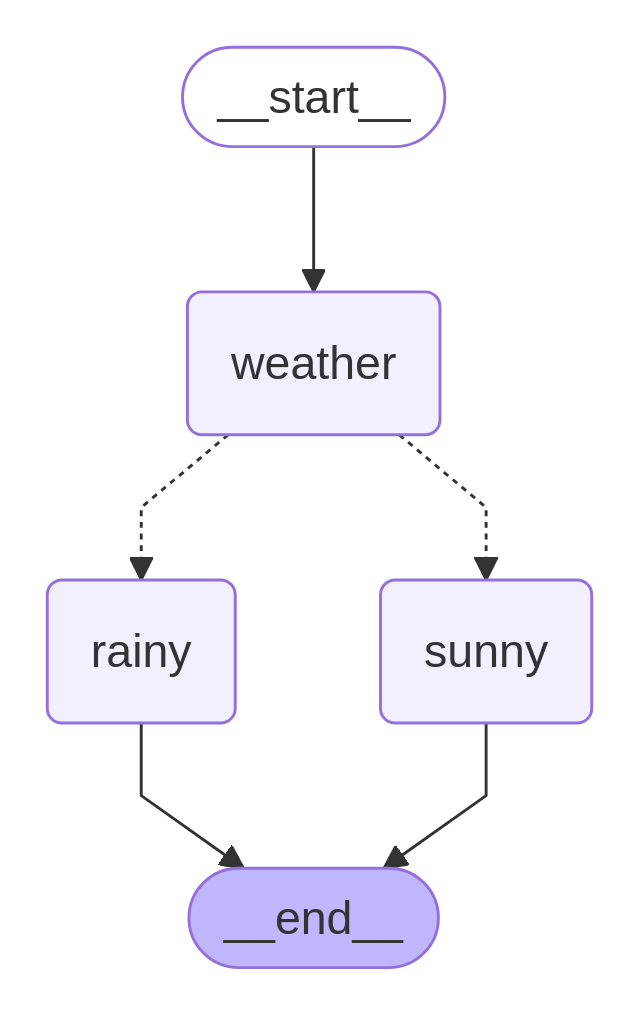

In [ ]:
# # Execute this code
# import nest_asyncio
# nest_asyncio.apply()

# # Code to draw graph
# from IPython.display import Image, display
# from langchain_core.runnables.graph import MermaidDrawMethod

# display(Image(app.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.PYPPETEER)))


In [ ]:
# invoke_val: State = {
#     "name": "ABC"
# }



In [ ]:
# type(invoke_val)

dict

In [ ]:
# app.invoke(invoke_val)

{'name': 'ABC', 'weather_info': "It's a rainy day today"}

In [ ]:
# 